# Train 3D CNN Classifier

This notebook trains a simple 3D CNN on the zebrafish tensor dataset using **time as channels**. To avoid leakage, it loads the persisted base dataset from notebook 5, splits train/validation/holdout on `original_instance_id`, and only then applies random XY rotation augmentation to the training subset.

In [10]:
%load_ext autoreload
%autoreload 2

import warnings

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

from src.ml import (
    TimeChannel3DCNNClassifier,
    augment_training_tensors_with_rotations,
    build_multitask_classification_reports,
    plot_confusion_matrices,
    plot_training_history,
    split_labeled_tensor_dataset_by_instance,
)
from src.notebook_utils import configure_full_dataframe_display
from src.tensor_utils import (
    build_tensor_embedding_2d,
    load_labeled_tensor_dataset,
    plot_tensor_embedding_2d,
)

warnings.filterwarnings("ignore", message="IProgress not found.*")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
configure_full_dataframe_display()

In [ ]:
# User inputs
# dataset_artifact_path:
#   relative path under .dataset_cache or an absolute path for the persisted dataset artifact from notebook 5.
#   Dataset composition is read from the saved metadata instead of being repeated in this notebook.
dataset_artifact_path = "moa_4class_c2_mca2_mtc32_rot8_t30_z5_y96_x96.pt"
# random_seed:
#   seed used for reproducible split assignment and training-time augmentation angles.
random_seed = 0

# Split and augmentation inputs
holdout_fraction = 0.25
validation_fraction_within_train = 0.2
train_num_random_rotations = 8
rotation_range_degrees = 5.0

# CNN inputs
conv_channels = (8, 16, 24, 32)
kernel_size_z = (1, 1, 1, 1)
kernel_size_xy = (5, 3, 3, 3)
stride_z = (1, 1, 1, 1)
stride_xy = (1, 1, 1, 1)
pool_kernel_z = (1, 1, 1, 1)
pool_kernel_xy = (2, 2, 2, 2)
pool_stride_z = (1, 1, 1, 1)
pool_stride_xy = (2, 2, 2, 2)
embedding_dim = 24
dropout = 0.5
action_weight = 1.0
compound_weight = 0.2
concentration_weight = 0.2

# Optimizer / training inputs
early_stopping_patience = 4
early_stopping_min_delta = 0.0
scheduler_patience = 1
scheduler_factor = 0.5
scheduler_min_lr = 1e-6

batch_size = 8
epochs = 20
learning_rate = 2e-4
weight_decay = 3e-3
device = None

# Embedding plot inputs
embedding_method = "umap"
umap_n_neighbors = 32
umap_min_dist = 0.1

In [4]:
# Load the base dataset persisted by notebook 5 so we split first and avoid rebuilding tensors here.
dataset = load_labeled_tensor_dataset(dataset_artifact_path)
metadata_all = dataset["metadata"].reset_index(drop=True).copy()

selected_mechanisms = [
    name for label, name in sorted(dataset["label_map"].items()) if int(label) != 0
]
selected_concentrations = sorted(
    metadata_all.loc[~metadata_all["is_control"], "concentration_band"].dropna().unique().tolist()
)
dataset_summary_df = pd.DataFrame(
    [
        {"metric": "dataset_artifact_path", "value": str(dataset_artifact_path)},
        {"metric": "n_examples", "value": int(dataset["tensors"].shape[0])},
        {"metric": "tensor_shape", "value": tuple(dataset["tensors"].shape)},
        {"metric": "n_classes_including_water", "value": int(len(dataset["label_map"]))},
        {"metric": "selected_mechanisms", "value": selected_mechanisms},
        {"metric": "selected_concentrations", "value": selected_concentrations},
        {"metric": "n_original_instances", "value": int(metadata_all["original_instance_id"].nunique()) if "original_instance_id" in metadata_all.columns else None},
    ]
)

display(dataset_summary_df)
display(metadata_all.groupby(["label", "label_name"]).size().reset_index(name="n_examples"))

,metric,value
0,dataset_artifact_path,moa_4class_t10_z3_y128_x128.pt
1,n_examples,837
2,tensor_shape,"(837, 10, 3, 128, 128)"
3,n_classes_including_water,5
4,selected_mechanisms,"[GABAAR_Antagonist, GABAAR_NegativeAllostericModulator, NMDAR_Activation, NMDAR_Antagonist]"
5,selected_concentrations,"[high, mid]"
6,n_original_instances,93


,label,label_name,n_examples
0,0,Water,288
1,1,GABAAR_Antagonist,144
2,2,GABAAR_NegativeAllostericModulator,144
3,3,NMDAR_Activation,117
4,4,NMDAR_Antagonist,144


In [5]:
splits = split_labeled_tensor_dataset_by_instance(
    dataset,
    holdout_fraction=holdout_fraction,
    validation_fraction_within_train=validation_fraction_within_train,
    random_state=random_seed,
)
metadata_all = splits.metadata_all
train_instance_ids = splits.train_instance_ids
val_instance_ids = splits.val_instance_ids
holdout_instance_ids = splits.holdout_instance_ids

X_train_base = splits.X_train_base
y_train_base = splits.y_train_base
metadata_train_base = splits.metadata_train_base
compound_train_base = splits.compound_train_base
concentration_train_base = splits.concentration_train_base

X_val = splits.X_val
y_val = splits.y_val
compound_val = splits.compound_val
concentration_val = splits.concentration_val
metadata_val = splits.metadata_val

X_holdout = splits.X_holdout
y_holdout = splits.y_holdout
compound_holdout = splits.compound_holdout
concentration_holdout = splits.concentration_holdout
metadata_holdout = splits.metadata_holdout

X_train, y_train, metadata_train = augment_training_tensors_with_rotations(
    X_train_base,
    y_train_base,
    metadata=metadata_train_base,
    num_random_rotations=train_num_random_rotations,
    rotation_range_degrees=rotation_range_degrees,
    random_state=random_seed,
)

split_summary_df = pd.DataFrame(
    [
        {"split": "train_base", "n_examples": int(len(X_train_base)), "n_original_instances": int(len(train_instance_ids))},
        {"split": "train_augmented", "n_examples": int(len(X_train)), "n_original_instances": int(len(train_instance_ids))},
        {"split": "val", "n_examples": int(len(X_val)), "n_original_instances": int(len(val_instance_ids))},
        {"split": "holdout", "n_examples": int(len(X_holdout)), "n_original_instances": int(len(holdout_instance_ids))},
    ]
)
display(split_summary_df)
compound_train = metadata_train["compound_label"].to_numpy()
concentration_train = metadata_train["concentration_label_id"].to_numpy()


,split,n_examples,n_original_instances
0,train_base,495,55
1,train_augmented,3465,55
2,val,126,14
3,holdout,216,24


In [6]:
model = TimeChannel3DCNNClassifier(
    conv_channels=conv_channels,
    kernel_size_z=kernel_size_z,
    kernel_size_xy=kernel_size_xy,
    stride_z=stride_z,
    stride_xy=stride_xy,
    pool_kernel_z=pool_kernel_z,
    pool_kernel_xy=pool_kernel_xy,
    pool_stride_z=pool_stride_z,
    pool_stride_xy=pool_stride_xy,
    embedding_dim=embedding_dim,
    dropout=dropout,
    action_weight=action_weight,
    compound_weight=compound_weight,
    concentration_weight=concentration_weight,
    batch_size=batch_size,
    epochs=epochs,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
    scheduler_patience=scheduler_patience,
    scheduler_factor=scheduler_factor,
    scheduler_min_lr=scheduler_min_lr,
    validation_split=0.1,
    random_state=random_seed,
    device=device,
    verbose=True,
)

model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    compound_y=compound_train,
    concentration_y=concentration_train,
    validation_compound_y=compound_val,
    validation_concentration_y=concentration_val,
)
model.history_

epoch 001/020 train_loss=1.4626 val_loss=1.3107 lr=2.00e-04 eta=40:12
epoch 002/020 train_loss=1.2299 val_loss=1.2292 lr=2.00e-04 eta=37:56
epoch 003/020 train_loss=1.0765 val_loss=1.1075 lr=2.00e-04 eta=35:49
epoch 004/020 train_loss=0.9868 val_loss=1.2032 lr=2.00e-04 eta=33:44
epoch 005/020 train_loss=0.9039 val_loss=1.1015 lr=2.00e-04 eta=31:37
epoch 006/020 train_loss=0.8425 val_loss=1.1332 lr=2.00e-04 eta=29:34
epoch 007/020 train_loss=0.7925 val_loss=1.2937 lr=1.00e-04 eta=29:30
epoch 008/020 train_loss=0.7586 val_loss=1.0064 lr=1.00e-04 eta=29:06
epoch 009/020 train_loss=0.7143 val_loss=1.0131 lr=1.00e-04 eta=27:56
epoch 010/020 train_loss=0.7084 val_loss=1.2242 lr=5.00e-05 eta=26:17
epoch 011/020 train_loss=0.6854 val_loss=0.9869 lr=5.00e-05 eta=24:18
epoch 012/020 train_loss=0.6782 val_loss=1.0661 lr=5.00e-05 eta=22:10
epoch 013/020 train_loss=0.6657 val_loss=0.9855 lr=5.00e-05 eta=19:51
epoch 014/020 train_loss=0.6697 val_loss=0.9461 lr=5.00e-05 eta=17:19
epoch 015/020 train_

,epoch,train_loss,val_loss
0,1,1.462630,1.310720
1,2,1.229886,1.229165
2,3,1.076467,1.107499
3,4,0.986806,1.203175
4,5,0.903872,1.101547
5,6,0.842461,1.133198
6,7,0.792511,1.293674
7,8,0.758618,1.006418
8,9,0.714252,1.013087
9,10,0.708398,1.224193


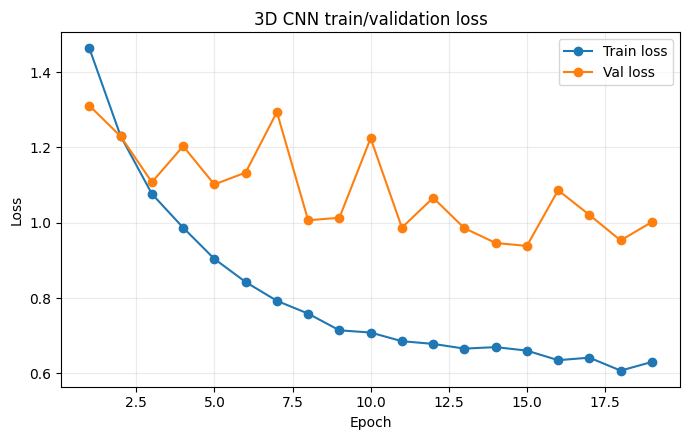

In [7]:
plot_training_history(model, title="3D CNN loss curves");

,precision,recall,f1-score,support
class,,,,
Water,0.650602,0.750000,0.696774,72.0
GABAAR_Antagonist,0.442623,0.750000,0.556701,36.0
GABAAR_NegativeAllostericModulator,0.818182,0.250000,0.382979,36.0
NMDAR_Activation,1.000000,0.805556,0.892308,36.0
NMDAR_Antagonist,0.437500,0.388889,0.411765,36.0


,value
accuracy,0.615741
macro_precision,0.669781
macro_recall,0.588889
macro_f1,0.588105
weighted_precision,0.666585
weighted_recall,0.615741
weighted_f1,0.606217
n_samples,216.000000
roc_auc_ovr_macro,0.879055
average_precision_macro,0.692834


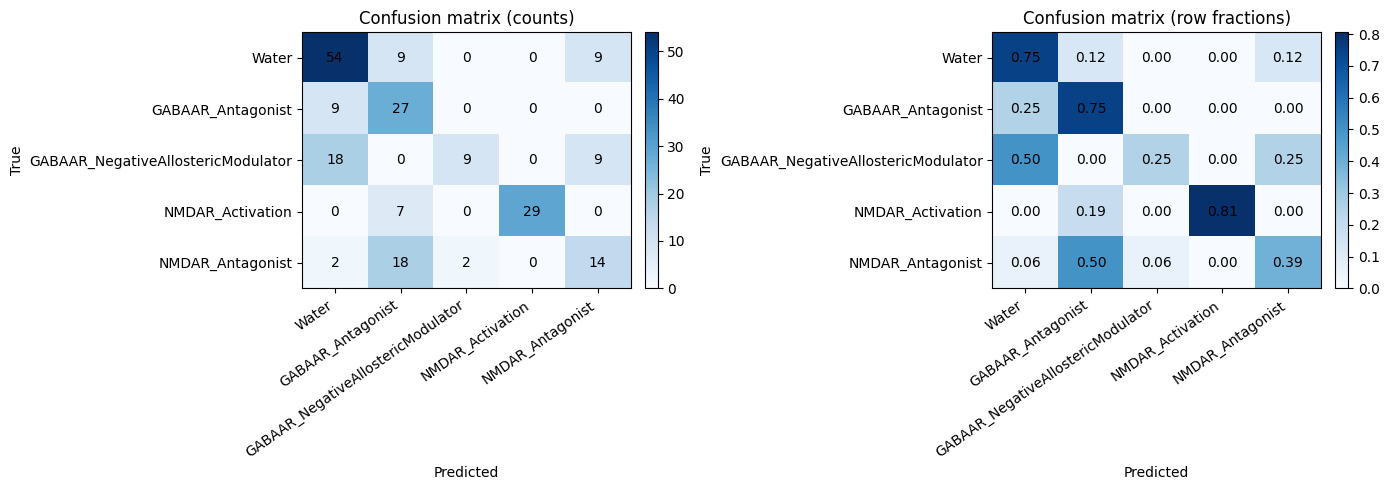

In [11]:
holdout_pred = model.predict(X_holdout)
holdout_proba = model.predict_proba(X_holdout)
report_bundle = build_multitask_classification_reports(
    {
        "action": y_holdout,
        "compound": compound_holdout,
        "concentration": concentration_holdout,
    },
    holdout_pred,
    y_proba=holdout_proba,
    class_labels={
        "action": model.classes_,
        "compound": model.compound_classes_,
        "concentration": model.concentration_classes_,
    },
    label_maps={
        "action": dataset["label_map"],
        "compound": dataset["compound_label_map"],
        "concentration": dataset["concentration_label_map"],
    },
)
for target, (per_class_report_df, summary_report_df) in report_bundle.items():
    print(f"\n## {target}")
    display(per_class_report_df)
    display(summary_report_df)
    plot_confusion_matrices(
        {"action": y_holdout, "compound": compound_holdout, "concentration": concentration_holdout}[target],
        holdout_pred[target],
        class_labels={
            "action": model.classes_,
            "compound": model.compound_classes_,
            "concentration": model.concentration_classes_,
        }[target],
        label_map={
            "action": dataset["label_map"],
            "compound": dataset["compound_label_map"],
            "concentration": dataset["concentration_label_map"],
        }[target],
    );

,embed_x,embed_y,label,label_name,method,original_instance_id,mechanism_of_action,compound,concentration_band,concentration_label,image_condition_dir,augmentation_index,rotation_degrees,is_control
0,19.416502,-6.228118,1,GABAAR_Antagonist,umap,3,GABAAR_Antagonist,Bemegride,high,1 mM,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/THIRD BATCH convulsants/Bemegride run 1 1 June 17/1mM F6,0,0.000000,False
1,19.238359,-6.035326,1,GABAAR_Antagonist,umap,3,GABAAR_Antagonist,Bemegride,high,1 mM,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/THIRD BATCH convulsants/Bemegride run 1 1 June 17/1mM F6,1,1.153851,False
2,19.363670,-6.197509,1,GABAAR_Antagonist,umap,3,GABAAR_Antagonist,Bemegride,high,1 mM,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/THIRD BATCH convulsants/Bemegride run 1 1 June 17/1mM F6,2,-1.163224,False
3,19.205481,-6.124224,1,GABAAR_Antagonist,umap,3,GABAAR_Antagonist,Bemegride,high,1 mM,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/THIRD BATCH convulsants/Bemegride run 1 1 June 17/1mM F6,3,4.972099,False
4,19.187386,-6.022201,1,GABAAR_Antagonist,umap,3,GABAAR_Antagonist,Bemegride,high,1 mM,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/THIRD BATCH convulsants/Bemegride run 1 1 June 17/1mM F6,4,4.808353,False


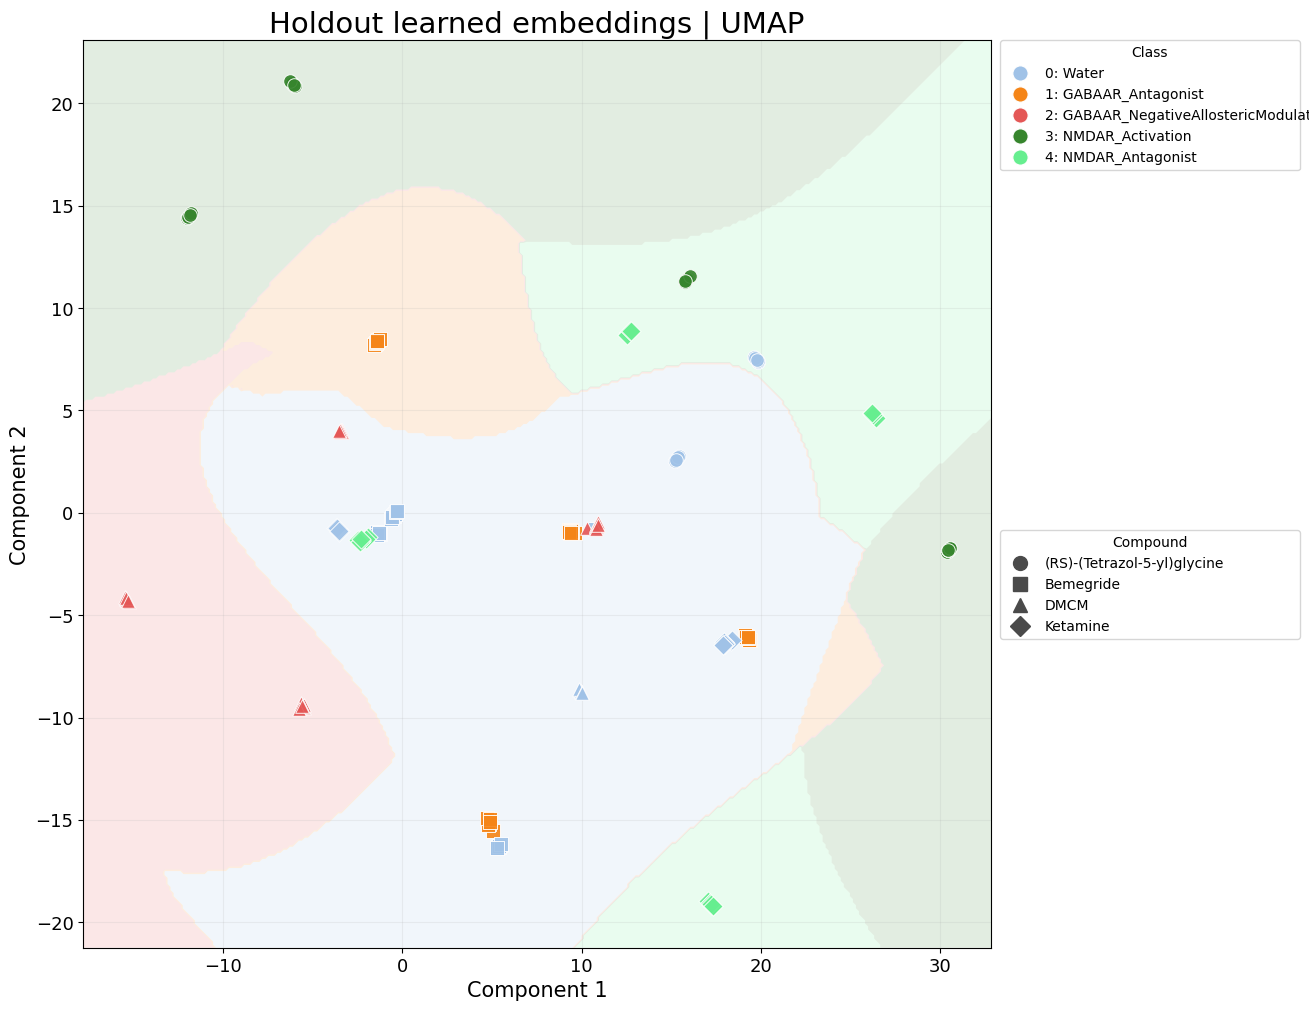

In [9]:
holdout_embeddings = torch.from_numpy(model.transform(X_holdout))
holdout_embedding_df = build_tensor_embedding_2d(
    holdout_embeddings,
    y_holdout,
    label_map=dataset["label_map"],
    metadata=metadata_holdout,
    method=embedding_method,
    random_state=random_seed,
    umap_n_neighbors=umap_n_neighbors,
    umap_min_dist=umap_min_dist,
)
display(holdout_embedding_df.head(5))
plot_tensor_embedding_2d(
    holdout_embedding_df,
    title=f"Holdout learned embeddings | {embedding_method.upper()}",
    marker_column="compound",
    show_svm_background=True,
);